In [1]:
import pandas as pd
import numpy as np
import nrrd
import matplotlib.pyplot as plt
import os
from pathlib import Path

current = Path().resolve()

while not (current / ".git").exists():
    current = current.parent

PROJECT_ROOT = current

output_folder = PROJECT_ROOT / "extension/etypes/"
data_folder = PROJECT_ROOT / "extension/"

In [2]:
# Create 2 slices of the 3D brain (300 axial, 200 transversal)

CCFv3a, _ = nrrd.read(f'{data_folder}/annotation_25_2022_CCFv3a.nrrd')

# Replace all zeros in CCFv3a with np.nan
CCFv3a = np.where(CCFv3a == 0, np.nan, CCFv3a)

#Slice
zindex_200 = 200
xindex_300 = 300

zslice_200 = np.transpose(CCFv3a[:, :, zindex_200])
xslice_300 = CCFv3a[xindex_300, :, :]

# Load densities

In the next cell you have to decide whether to include unassigned regions in the visualisation


In [11]:
#file = 'brain_regions_e_types_composition.csv'
file_path = os.path.join(data_folder, "data/brain__with_unassigned_regions_e_types_composition.csv")
data_df = pd.read_csv(file_path, index_col=0)

In [12]:
# We load brain regon hierarchty: parcellation_to_parcellation_term_membership_extend
file_path = os.path.join(data_folder, "../densities_app/parcellation_to_parcellation_term_membership_extend.csv")

parcellation_annotation = pd.read_csv(file_path) 
#Get all ids i.e.  label_numbers and leaf regions i.e. 667 FRP23
ids = parcellation_annotation[parcellation_annotation['cluster_as_filename'].isin(data_df.index)][['label_numbers', 'cluster_as_filename']]

In [13]:
# Combine the two levels of the MultiIndex into one
# data_df.columns = [f"{col[0]}|{col[1]}" for col in data_df.columns]

data_df.shape

(719, 11)

In [14]:
data_df.head()

,bAC,bIR,bNAC,bSTUT,cAC,cADpyr,cIR,cNAC,cSTUT,dNAC,dSTUT
AAA,13642.960359,7388.022628,12678.735695,2939.319168,21618.896401,11435.747609,2537.236585,6218.253955,3614.333926,1752.112101,3021.531537
ACAd1,2799.640015,1121.977282,1715.824896,190.197327,2006.112983,7037.917440,146.280937,513.474338,224.182900,111.887536,476.844270
ACAd23,13098.155452,5396.225645,8453.156564,1068.118307,10729.650630,63898.354311,813.971276,2714.385602,1278.890566,675.691549,2412.390998
ACAd5,6960.326343,3182.832919,5021.448421,866.551337,7442.602045,23646.689691,719.415675,2128.219118,1037.014350,488.061687,1217.290268
ACAd6a,11254.728651,4587.390288,6578.258284,734.551204,6913.793904,47203.835802,680.841571,2201.730703,824.338643,233.284512,1345.832847


In [15]:
# Generate df of ids with m-densities

# Ensure matching data types (both should be strings)
data_df.index = data_df.index.astype(str)
ids['cluster_as_filename'] = ids['cluster_as_filename'].astype(str)

# Reset index to make df.index a column
data_df.reset_index(inplace=True)

In [17]:
data_df.head()

,index,bAC,bIR,bNAC,bSTUT,cAC,cADpyr,cIR,cNAC,cSTUT,dNAC,dSTUT
0,AAA,13642.960359,7388.022628,12678.735695,2939.319168,21618.896401,11435.747609,2537.236585,6218.253955,3614.333926,1752.112101,3021.531537
1,ACAd1,2799.640015,1121.977282,1715.824896,190.197327,2006.112983,7037.917440,146.280937,513.474338,224.182900,111.887536,476.844270
2,ACAd23,13098.155452,5396.225645,8453.156564,1068.118307,10729.650630,63898.354311,813.971276,2714.385602,1278.890566,675.691549,2412.390998
3,ACAd5,6960.326343,3182.832919,5021.448421,866.551337,7442.602045,23646.689691,719.415675,2128.219118,1037.014350,488.061687,1217.290268
4,ACAd6a,11254.728651,4587.390288,6578.258284,734.551204,6913.793904,47203.835802,680.841571,2201.730703,824.338643,233.284512,1345.832847


In [18]:
# Merge based on df.index and ids.cluster_as_filename
merged_df = pd.merge(data_df, ids, left_on='index', right_on='cluster_as_filename')

# Optionally set the 'index' back as the index and clean up
merged_df.set_index('index', inplace=True)
merged_df.drop(columns='cluster_as_filename', inplace=True)
merged_df.index.name = None

In [19]:
merged_df.head(3)

,bAC,bIR,bNAC,bSTUT,cAC,cADpyr,cIR,cNAC,cSTUT,dNAC,dSTUT,label_numbers
AAA,13642.960359,7388.022628,12678.735695,2939.319168,21618.896401,11435.747609,2537.236585,6218.253955,3614.333926,1752.112101,3021.531537,23
AAA,13642.960359,7388.022628,12678.735695,2939.319168,21618.896401,11435.747609,2537.236585,6218.253955,3614.333926,1752.112101,3021.531537,23
ACAd1,2799.640015,1121.977282,1715.824896,190.197327,2006.112983,7037.917440,146.280937,513.474338,224.182900,111.887536,476.844270,935


CPU times: user 85.4 ms, sys: 1.17 ms, total: 86.6 ms
Wall time: 92 ms


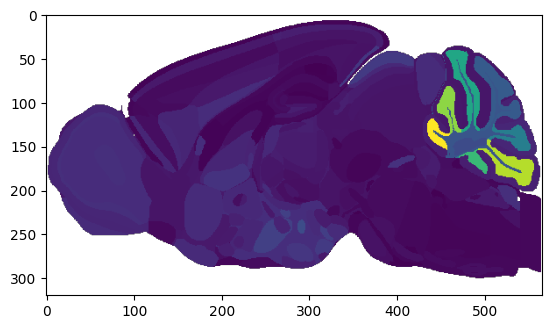

In [20]:
%%time

# Prepare the label mapping
me_type = 'bAC'
label_numbers = merged_df['label_numbers'].values
cluster_values = merged_df[me_type].values
label_to_cluster = dict(zip(label_numbers, cluster_values))

# Define the worker function
def process_CCFv3a(CCFv3a, label_to_cluster, label_numbers):

    new_CCFv3a = np.full_like(CCFv3a, np.nan)

    for label in label_numbers:
        new_CCFv3a[CCFv3a == label] = label_to_cluster[label]
        
    # Retain existing np.nan values from the original CCFv3a
    nan_mask = np.isnan(CCFv3a)
    new_CCFv3a[nan_mask] = np.nan
    
    # Set 0 where values have not been populated
    new_CCFv3a[(~nan_mask) & (new_CCFv3a == np.nan)] = 0
    
    return new_CCFv3a


new_CCFv3a = process_CCFv3a(zslice_200, label_to_cluster, label_numbers)
plt.imshow(new_CCFv3a);

In [21]:
type_names = list(data_df.columns[0:])

In [22]:
if 'index' in type_names:
    type_names.remove('index')

In [23]:
%%time

label_numbers = merged_df['label_numbers'].values

for e_type in type_names:
    cluster_values = merged_df[e_type].values
    label_to_cluster = dict(zip(label_numbers, cluster_values))
    me_transv = process_CCFv3a(zslice_200, label_to_cluster, label_numbers)
    np.save(os.path.join(output_folder, f"transversal/{e_type}_transv_200.npy"), me_transv)
    me_axial = process_CCFv3a(xslice_300, label_to_cluster, label_numbers)
    np.save(os.path.join(output_folder, f"axial/{e_type}_axial_300.npy"), me_axial)
    # print(f"{e_type} saved.")

CPU times: user 6.06 s, sys: 8.83 ms, total: 6.07 s
Wall time: 6.07 s


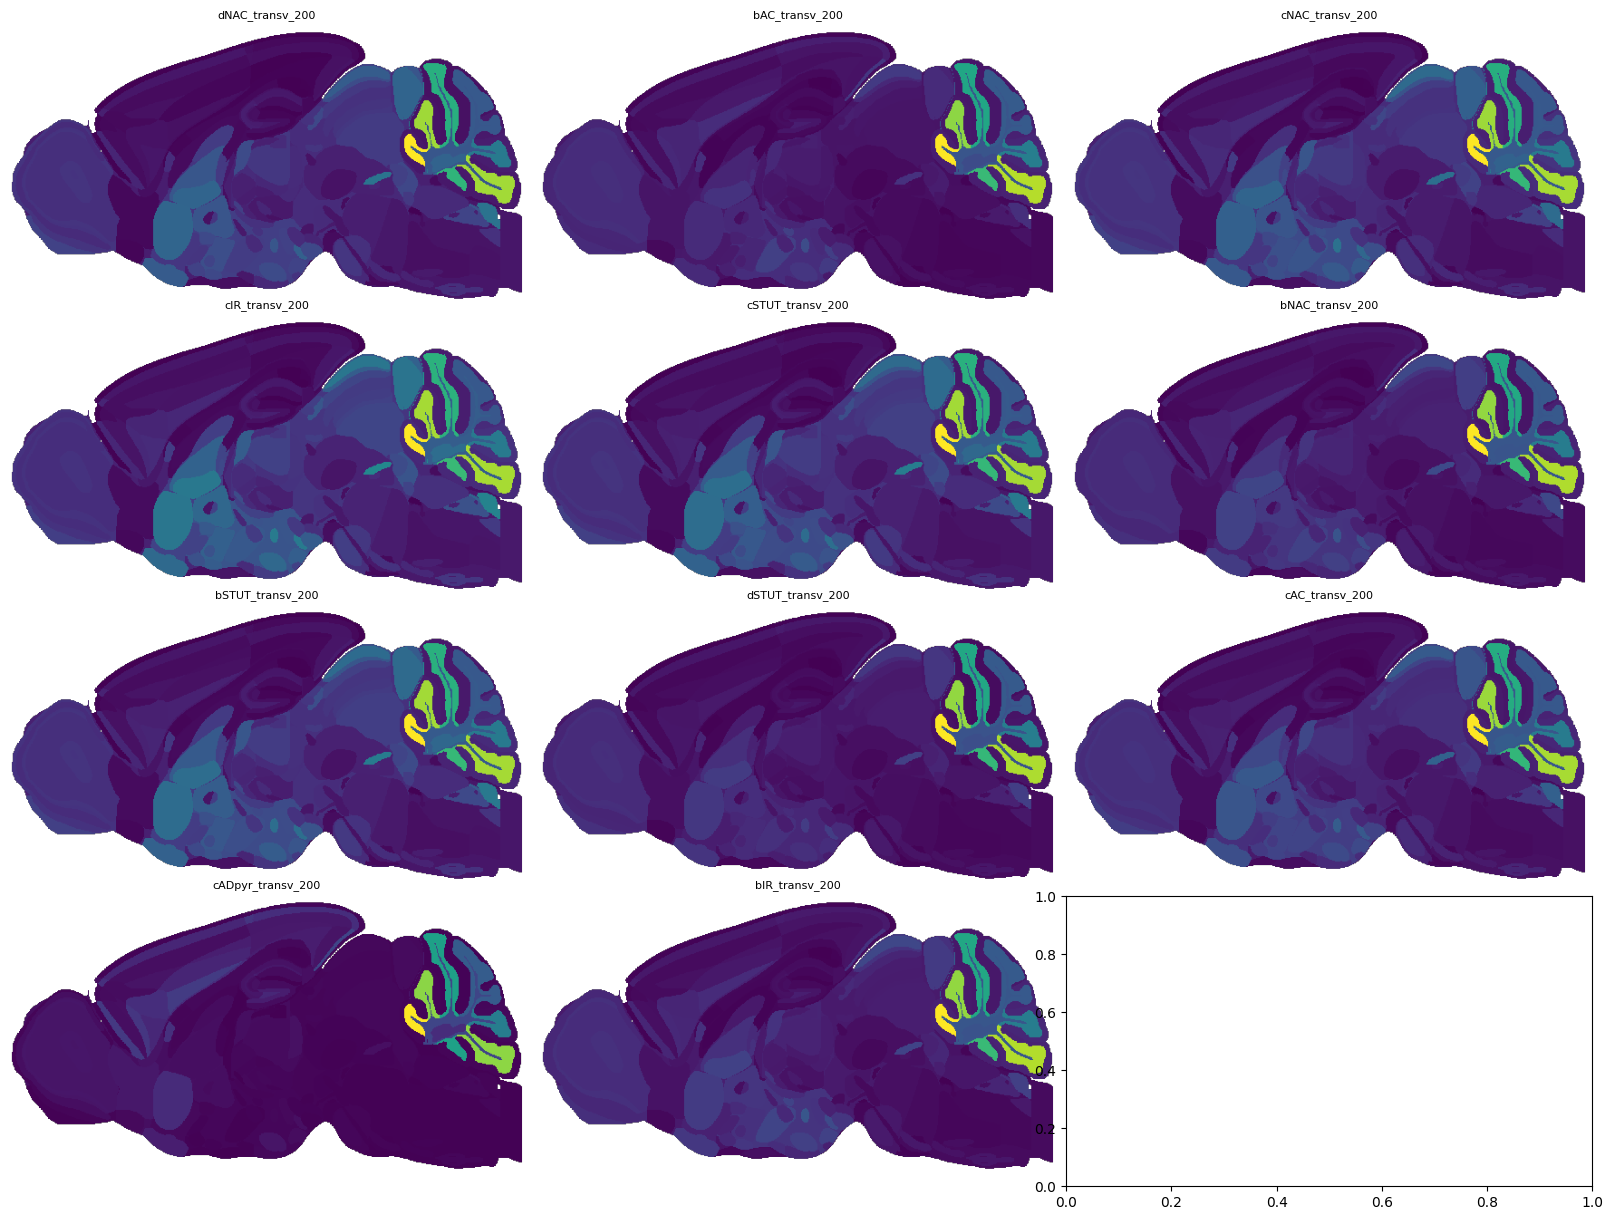

In [25]:
input_folder = os.path.join(output_folder, "transversal")
# input_folder = os.path.join(output_folder, "axial")


# List all .npy files
files = [f for f in os.listdir(input_folder) if f.endswith(".npy")]

# Take the first 9 files (or any 9)
files = files[:11]

# Create a figure with 3x3 subplots
fig, axes = plt.subplots(4, 3, figsize=(16, 12))

for i, file in enumerate(files):
    # Load the npy file
    arr = np.load(os.path.join(input_folder, file))
    
    # Determine subplot position
    row, col = divmod(i, 3)
    
    # Show image
    axes[row, col].imshow(arr, cmap='viridis')  # change cmap if needed
    axes[row, col].set_title(file[:-4], fontsize=8)
    axes[row, col].axis('off')  # remove axis ticks

# Tight layout to avoid overlap
plt.tight_layout(pad=0)  # pad controls spacing between subplots
plt.subplots_adjust(wspace=0.01, hspace=0.00)
# plt.savefig("../extension/composite.png", bbox_inches='tight', pad_inches=0)
plt.show()